### 1. Dataset Selection

For this project, We selected the **Telecom Customer Churn dataset**, which represents a real-world business problem of customer retention.

This dataset is considered "messy" because:
- It contains **missing values** (e.g., TotalCharges)
- Some columns have **incorrect data types** (object instead of numeric)
- It includes **categorical variables** that require encoding
- There is **class imbalance** in the target variable (Churn)

This makes it suitable for demonstrating real-world data preprocessing skills.

### 2. Problem Statement

The goal of this project is to predict whether a customer will **churn (leave the telecom service)** or not.

Customer churn is a critical problem for telecom companies because:
- Acquiring new customers is more expensive than retaining existing ones
- Identifying potential churners helps companies take preventive actions

This is a **binary classification problem**, where:
- 1 → Customer churns
- 0 → Customer stays

### 3. Machine Learning Approach

This project follows a **Supervised Learning** approach.

Reason:
- The dataset contains a **target variable (Churn)**
- We train the model using labeled data (input features + known output)

The chosen model is:
- **Logistic Regression**

Why Logistic Regression?
- Works well for binary classification
- Easy to interpret
- Provides probability outputs

In [1002]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### 4. Loading The Data

In [1003]:
churn_data = pd.read_csv("Telco-Customer-Churn.csv")

churn_data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### 5. Check Basic Info

In [1004]:
print(churn_data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [1005]:
churn_data.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [1006]:
churn_data.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64



### 6. Data Cleaning Strategy

To prepare the dataset for model training, several data cleaning and preprocessing steps were performed:

#### a) Handling Missing Values
- The `TotalCharges` column did not initially show missing values but contained **empty strings ("")**
- These empty strings were first converted to **NaN values**
- After conversion, rows with missing values were removed

#### b) Removing Duplicates
- Checked for duplicate records in the dataset
- Removed duplicate rows to ensure data quality and avoid bias in training

#### c) Dropping Irrelevant Columns
- The `customerID` column was removed because:
  - It is a unique identifier
  - It does not contribute to predicting churn

#### d) Fixing Target Variable (Churn)
- Converted the target variable `Churn` into numerical format:
  - Yes → 1
  - No → 0

#### e) Standardizing Binary Columns
- Several columns contained values like:
  - "Yes", "No"
  - "No phone service"
  - "No internet service"

- These were standardized by converting:
  - "No phone service" → "No"
  - "No internet service" → "No"

- After standardization, all such columns were encoded as:
  - Yes → 1
  - No → 0

#### f) Encoding Categorical Variables
- Remaining categorical variables were converted into numerical format using:
  - **One-Hot Encoding (get_dummies)**

#### g) Feature Scaling
- Applied **StandardScaler** to normalize numerical features

#### h) Handling Imbalanced Data
- The dataset had class imbalance in the target variable (Churn)

To address this, two approaches were used:

1. **SMOTE (Synthetic Minority Oversampling Technique)**  
   - Generated synthetic samples of the minority class  
   - Helped balance the dataset before training  

2. **Class Weight Adjustment in Logistic Regression**  
   - Used `class_weight = "balanced"` in Logistic Regression  
   - This forces the model to give more importance to the minority class (churn cases)  
---

These steps ensured that the dataset became clean, consistent, and suitable for machine learning modeling.

In [1007]:
(churn_data["TotalCharges"]==" ").sum()   #not null but empty string (have to remove)

np.int64(11)

##### Convert TotalCharges (if object → numeric)

In [1008]:
churn_data["TotalCharges"] = pd.to_numeric(churn_data["TotalCharges"],errors="coerce")

In [1009]:
churn_data.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [1010]:
(churn_data=="").sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

#### Handle Missing Values

In [1011]:
churn_data.dropna(inplace=True)

In [1012]:
churn_data.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [1013]:
churn_data.shape

(7032, 21)

In [1014]:
# remove useless column

churn_data.drop("customerID",axis=1,inplace=True)

In [1015]:
churn_data

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [1016]:
# Lets fix target output
churn_data["Churn"] = churn_data["Churn"].map({"Yes":1,"No":0})

#### Handling Duplicate Values

In [1017]:
churn_data.duplicated().sum()

np.int64(22)

In [1018]:
churn_data.drop_duplicates(inplace=True)
churn_data

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,0
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,0
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,0
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,1


#### Unique Values For Each Column

In [1019]:
for col in churn_data.columns:
    print(col, churn_data[col].unique())

gender ['Female' 'Male']
SeniorCitizen [0 1]
Partner ['Yes' 'No']
Dependents ['No' 'Yes']
tenure [ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26 39]
PhoneService ['No' 'Yes']
MultipleLines ['No phone service' 'No' 'Yes']
InternetService ['DSL' 'Fiber optic' 'No']
OnlineSecurity ['No' 'Yes' 'No internet service']
OnlineBackup ['Yes' 'No' 'No internet service']
DeviceProtection ['No' 'Yes' 'No internet service']
TechSupport ['No' 'Yes' 'No internet service']
StreamingTV ['No' 'Yes' 'No internet service']
StreamingMovies ['No' 'Yes' 'No internet service']
Contract ['Month-to-month' 'One year' 'Two year']
PaperlessBilling ['Yes' 'No']
PaymentMethod ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
MonthlyCharges [29.85 56.95 53.85 ... 63.1  44.2  78.7 ]
TotalCharges [  29.85 1889.5   

In [1020]:
cols = [
"OnlineSecurity",
"OnlineBackup",
"DeviceProtection",
"TechSupport",
"StreamingTV",
"StreamingMovies"
]

for col in cols:
    churn_data[col] = churn_data[col].replace("No internet service","No")


In [1021]:
churn_data["MultipleLines"]= churn_data["MultipleLines"].replace("No phone service","No")

#### Converting Categorial to Numerical (Yes->1, No->0)

In [1022]:

cols =[
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "PaperlessBilling"
]

for col in cols:
    churn_data[col] = churn_data[col].map({'Yes':1,'No':0})



churn_data['gender'] = churn_data['gender'].map({'Male':1,'Female':0})

for col in churn_data.columns:
    print(col, churn_data[col].unique())



gender [0 1]
SeniorCitizen [0 1]
Partner [1 0]
Dependents [0 1]
tenure [ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26 39]
PhoneService [0 1]
MultipleLines [0 1]
InternetService ['DSL' 'Fiber optic' 'No']
OnlineSecurity [0 1]
OnlineBackup [1 0]
DeviceProtection [0 1]
TechSupport [0 1]
StreamingTV [0 1]
StreamingMovies [0 1]
Contract ['Month-to-month' 'One year' 'Two year']
PaperlessBilling [1 0]
PaymentMethod ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
MonthlyCharges [29.85 56.95 53.85 ... 63.1  44.2  78.7 ]
TotalCharges [  29.85 1889.5   108.15 ...  346.45  306.6  6844.5 ]
Churn [0 1]


#### Imbalanced Data

In [1023]:
churn_data["Churn"].value_counts()      

Churn
0    5153
1    1857
Name: count, dtype: int64

In [1024]:
churn_data["Churn"].value_counts(normalize=True)*100  #percentage

Churn
0    73.509272
1    26.490728
Name: proportion, dtype: float64

### 7. Exploratory Data Analysis (EDA)

To understand the dataset and identify patterns affecting customer churn, several visualizations and analyses were performed:

#### a) Churn Distribution
- Analyzed the overall distribution of the target variable (Churn)
- Observed that the dataset is **imbalanced**, with more non-churn customers than churn customers

---

#### b) Senior Citizen vs Churn
- Compared churn behavior between senior citizens and non-senior citizens
- Found that **senior citizens tend to churn more frequently** than non-senior customers

---

#### c) Tenure vs Churn
- Used boxplot analysis to study customer tenure
- Observed that:
  - Customers with **lower tenure are more likely to churn**
  - Long-term customers tend to stay

---

#### d) Contract Type vs Churn
- Analyzed different contract types (Month-to-month, One year, Two year)
- Found that:
  - **Month-to-month contracts have the highest churn rate**
  - Long-term contracts (1 year, 2 year) have significantly lower churn

---

#### e) Monthly Charges vs Churn
- Compared monthly charges across churn and non-churn customers
- Observed that:
  - Customers with **higher monthly charges are more likely to churn**

---

#### f) Internet Service vs Churn
- Studied churn behavior across different internet service types
- Identified variations in churn rates depending on the service type

---

#### G) Additional Services Analysis
- Analyzed services like:
  - Streaming TV
  - Streaming Movies
  - Online Security
  - Device Protection
  - Tech Support

- Key insight:
  - Customers **without additional services (especially security and support)** tend to churn more

---

#### h) Payment Method vs Churn
- Compared churn across different payment methods
- Found that:
  - Customers using **Electronic Check have the highest churn rate**

---

### Key Insights from EDA

- Customers with **short tenure**, **high monthly charges**, and **month-to-month contracts** are more likely to churn
- **Senior citizens** show higher churn behavior
- Lack of **additional services (security/support)** increases churn probability
- **Electronic check users** are more likely to leave

---

These insights helped guide feature selection and model building decisions.

<Axes: xlabel='Churn', ylabel='count'>

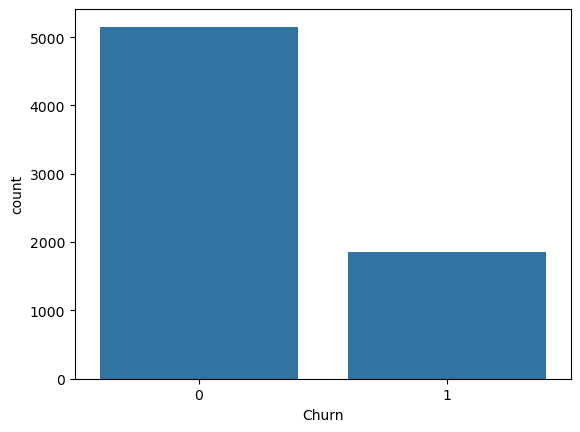

In [1025]:
sns.countplot(x="Churn", data=churn_data)

<Axes: xlabel='SeniorCitizen', ylabel='count'>

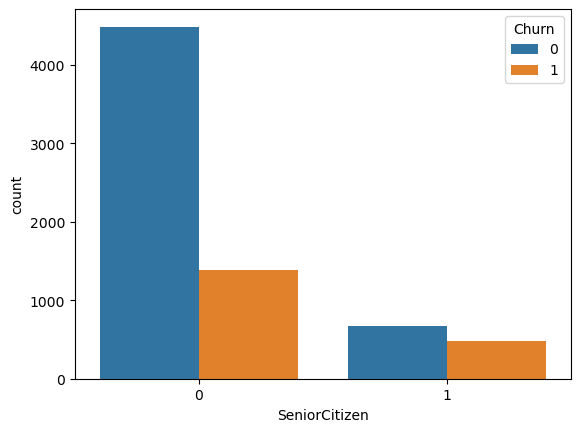

In [1026]:
sns.countplot( x="SeniorCitizen", hue="Churn", data=churn_data)

<Axes: xlabel='Churn', ylabel='tenure'>

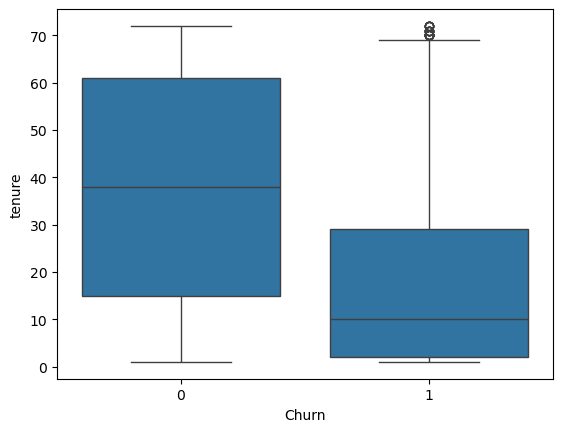

In [1027]:
sns.boxplot(x="Churn", y="tenure",data=churn_data)

Contract  Month-to-month  One year  Two year
Churn                                       
0                   2210      1306      1637
1                   1643       166        48


<Axes: xlabel='Contract', ylabel='count'>

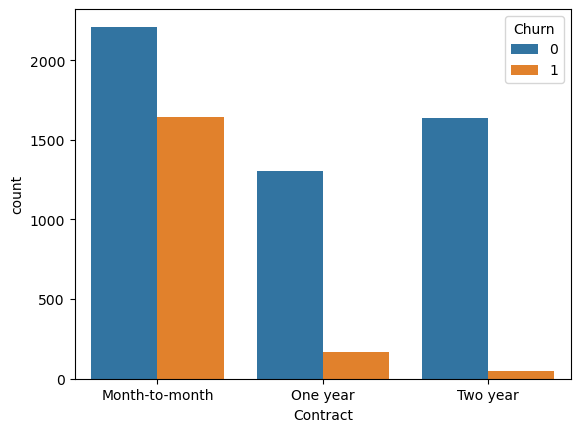

In [1028]:
print(pd.crosstab(churn_data["Churn"], churn_data["Contract"]))

sns.countplot(x="Contract", hue="Churn", data=churn_data)

<Axes: xlabel='Churn', ylabel='MonthlyCharges'>

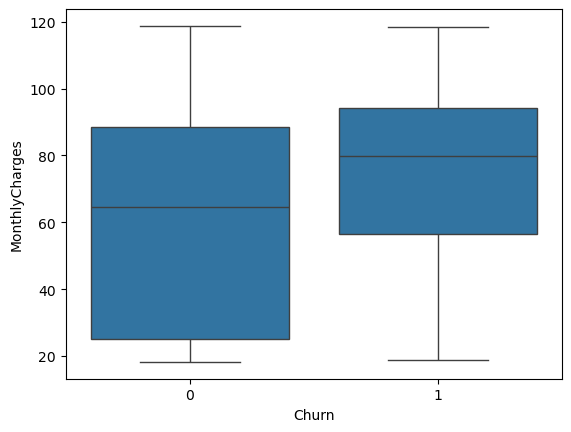

In [1029]:
sns.boxplot(x="Churn", y="MonthlyCharges",data=churn_data)
 
#you can see those who leave company have high monthly charges

InternetService   DSL  Fiber optic    No
Churn                                   
0                1957         1799  1397
1                 457         1291   109


<Axes: xlabel='InternetService', ylabel='count'>

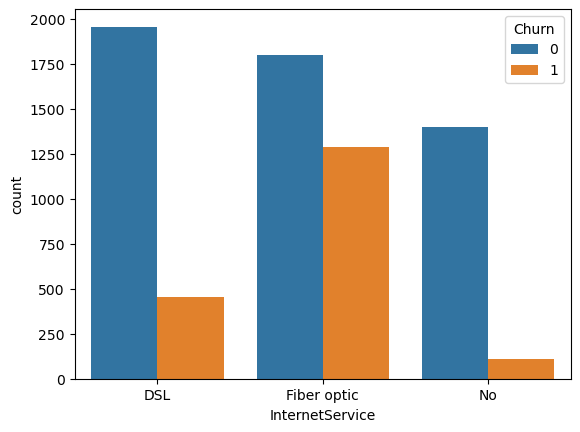

In [1030]:
print(pd.crosstab(churn_data["Churn"], churn_data["InternetService"]))


sns.countplot(x="InternetService", hue="Churn", data=churn_data)

# customers with fiber optic are leaving more as fiber optic is expensive

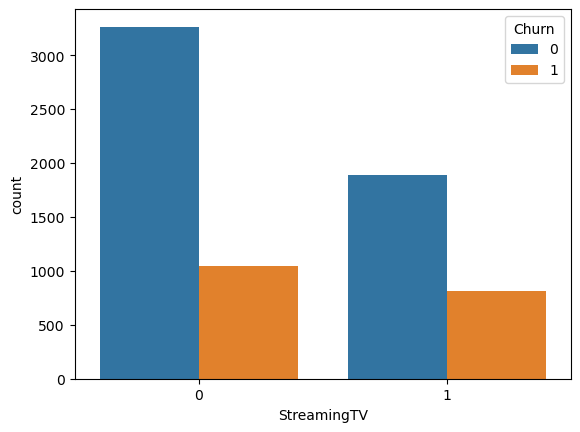

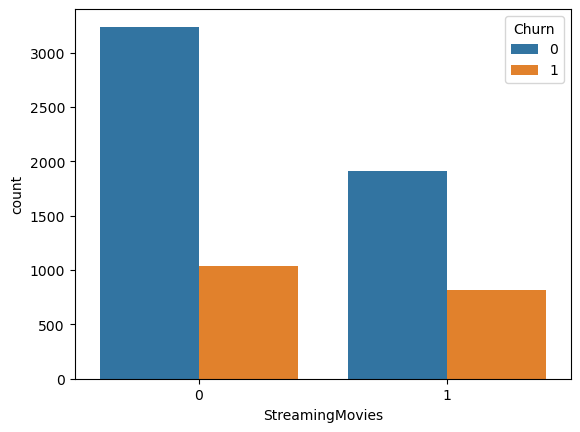

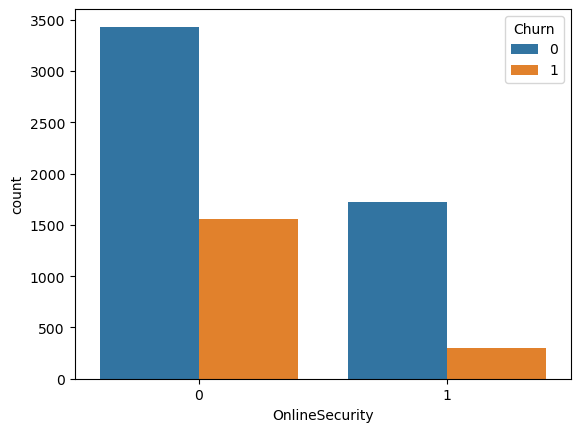

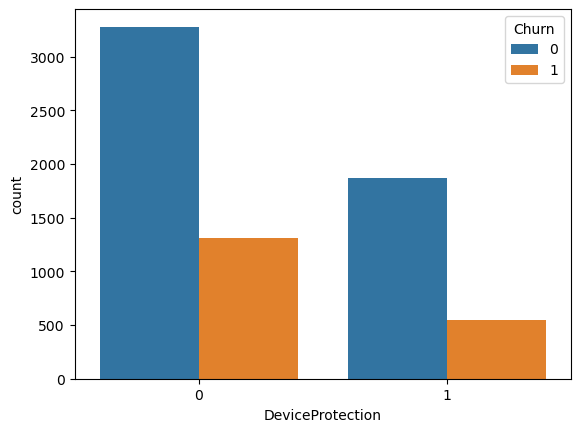

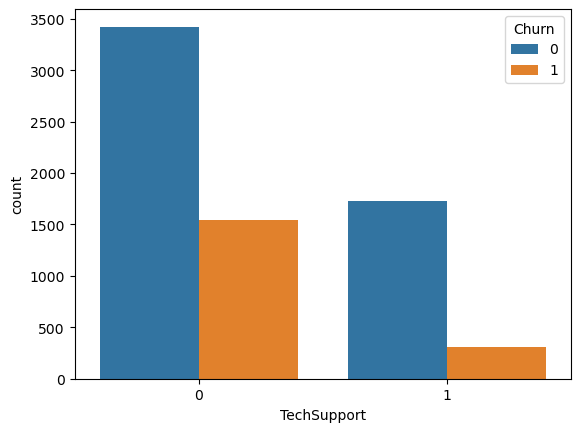

In [1031]:
col=["StreamingTV", "StreamingMovies","OnlineSecurity","DeviceProtection","TechSupport"]

for col in col:
    sns.countplot(x=col,hue="Churn", data=churn_data)
    plt.show()

PaymentMethod  Bank transfer (automatic)  Credit card (automatic)  \
Churn                                                               
0                                   1284                     1289   
1                                    258                      232   

PaymentMethod  Electronic check  Mailed check  
Churn                                          
0                          1294          1286  
1                          1065           302  


([0, 1, 2, 3],
 [Text(0, 0, 'Electronic check'),
  Text(1, 0, 'Mailed check'),
  Text(2, 0, 'Bank transfer (automatic)'),
  Text(3, 0, 'Credit card (automatic)')])

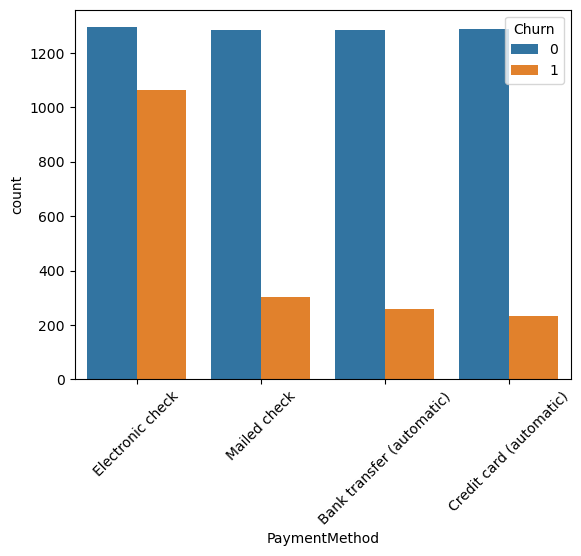

In [1032]:
print(pd.crosstab(churn_data["Churn"], churn_data["PaymentMethod"]))

# customers with payment method of electronic check are have more churn (leaving more)

sns.countplot(x="PaymentMethod", hue="Churn", data=churn_data)
plt.xticks(rotation=45)

In [1033]:
pd.crosstab(churn_data["Churn"], churn_data["TechSupport"])

TechSupport,0,1
Churn,,
0,3423,1730
1,1547,310


In [1034]:
# from the data we will use 6 parameters as input features which have impact on customer churn

# 1. Gender
# 1. Tenure
# 2. MonthlyCharges
# 3. Contract
# 4. Internet Services
# 5. Online Security
# 6. Tech Support

churn_data.columns


Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

### 8. Feature Selection

After performing Exploratory Data Analysis (EDA), relevant features were selected based on their impact on customer churn.

#### Selected Features

The following features were chosen for model training:

- Customer Demographics:
  - Gender
  - SeniorCitizen

- Customer Usage & Behavior:
  - Tenure
  - MonthlyCharges
  - TotalCharges

- Service & Subscription Details:
  - Contract
  - InternetService
  - OnlineSecurity
  - DeviceProtection
  - TechSupport
  - StreamingMovies
  - StreamingTV
  - PhoneService

- Payment Information:
  - PaymentMethod

---

#### Target Variable
- Churn (0 → No, 1 → Yes)

---

#### Reason for Feature Selection

Features were selected based on insights from EDA:

- **Tenure & Charges**:
  - Customers with low tenure and high monthly charges showed higher churn

- **Contract Type**:
  - Month-to-month contracts had significantly higher churn rates

- **Services (Security, Support, etc.)**:
  - Customers without additional services were more likely to churn

- **Payment Method**:
  - Electronic check users showed higher churn behavior

- **Senior Citizen**:
  - Senior citizens had a higher tendency to churn

---

#### Why These Features?

- These features showed **strong correlation or patterns with churn**
- Removed irrelevant features like `customerID` which do not contribute to prediction
- Focused on features that represent:
  - Customer behavior
  - Service usage
  - Billing patterns

---

This feature selection helps improve model performance by:
- Reducing noise
- Improving interpretability
- Focusing on the most impactful variables

In [1035]:
features = [
    "gender",
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges", 
    "Contract",
    "InternetService",
    "OnlineSecurity",
    "DeviceProtection",
    "TechSupport",
    "StreamingMovies",
    "StreamingTV",
    "PaymentMethod",  
    "PhoneService",   
]

x  = churn_data[features]
y  = churn_data["Churn"]

#### One-Hot Encoding

`pd.get_dummies(X)` is used to convert categorical features into numerical format.

- It creates new binary columns (0/1) for each category in a feature
- Each category becomes a separate column
- Helps machine learning models understand categorical data without assuming any order

This method is preferred over label encoding because it avoids introducing false relationships between categories.

In [1036]:
X = pd.get_dummies(x)

In [1037]:
bool_col = X.select_dtypes(include="bool").columns

X[bool_col]=X[bool_col].astype(int)

X.info()


<class 'pandas.core.frame.DataFrame'>
Index: 7010 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   gender                                   7010 non-null   int64  
 1   SeniorCitizen                            7010 non-null   int64  
 2   tenure                                   7010 non-null   int64  
 3   MonthlyCharges                           7010 non-null   float64
 4   TotalCharges                             7010 non-null   float64
 5   OnlineSecurity                           7010 non-null   int64  
 6   DeviceProtection                         7010 non-null   int64  
 7   TechSupport                              7010 non-null   int64  
 8   StreamingMovies                          7010 non-null   int64  
 9   StreamingTV                              7010 non-null   int64  
 10  PhoneService                             7010 non-nul

### 9. Train-Test Split

The dataset is split into training and testing sets using `train_test_split()`.

- 80% of the data is used for training the model
- 20% of the data is used for testing the model
- `random_state=42` ensures reproducibility of results

This helps evaluate how well the model performs on unseen data.

In [1038]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(X,y, test_size=0.2, random_state=42)


In [1039]:
x_train_scaled = x_train.copy()
x_test_scaled = x_test.copy()

#### Feature Scaling

Feature scaling was applied using **StandardScaler** to normalize numerical features.

- The columns scaled were:
  - tenure
  - MonthlyCharges
  - TotalCharges

- StandardScaler transforms data so that:
  - Mean = 0
  - Standard Deviation = 1

- `fit_transform()` was applied on training data  
- `transform()` was applied on test data to avoid data leakage

This helps improve model performance by ensuring all features are on a similar scale.

In [1040]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
num_cols = ["tenure","MonthlyCharges","TotalCharges"]

x_train_scaled[num_cols] = scaler.fit_transform(x_train[num_cols])
x_test_scaled[num_cols] = scaler.transform(x_test[num_cols])



### 10. Model Training

Three different models were trained and evaluated to identify the best approach for predicting customer churn.

---

#### a) Logistic Regression (Baseline Model)

- A basic Logistic Regression model was trained using the original dataset
- `class_weight = "balanced"` was used to handle class imbalance

**Why this model?**
- Simple and interpretable
- Works well for binary classification problems
- Provides a strong baseline for comparison

---

#### b) Logistic Regression with SMOTE

- SMOTE (Synthetic Minority Oversampling Technique) was applied to balance the dataset
- Logistic Regression was then trained on the resampled data

**Why this approach?**
- Helps the model learn better patterns for the minority class (churn)
- Aims to improve Recall by reducing False Negatives

---

#### c) Logistic Regression with Hyperparameter Tuning

- GridSearchCV was used to find the optimal parameters for Logistic Regression
- Best parameters included:
  - L1 regularization
  - Optimal value of C
  - Suitable solver (liblinear)

**Why this approach?**
- Improves model performance by finding the best configuration
- Reduces overfitting
- Enhances generalization on unseen data

---

### Summary

- The baseline model provides a reference point
- SMOTE focuses on improving minority class prediction
- Hyperparameter tuning optimizes overall model performance

These models were compared using metrics such as Accuracy, Recall, and Precision to select the best performing model.

In [1041]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced"
)

model.fit(x_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=2000)

In [ ]:
y_pred = model.predict(x_test_scaled)
from sklearn.metrics import accuracy_score,confusion_matrix,recall_score,precision_score,classification_report,f1_score

print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(precision_score(y_test,y_pred))
print(recall_score(y_test,y_pred))
print(classification_report(y_test,y_pred))


0.7410841654778887
[[771 310]
 [ 53 268]]
0.46366782006920415
0.8348909657320872
              precision    recall  f1-score   support

           0       0.94      0.71      0.81      1081
           1       0.46      0.83      0.60       321

    accuracy                           0.74      1402
   macro avg       0.70      0.77      0.70      1402
weighted avg       0.83      0.74      0.76      1402



In [1043]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

x_train_smote, y_train_smote = smote.fit_resample(x_train_scaled, y_train)

In [1044]:
print(y_train.value_counts())
print(y_train_smote.value_counts())


Churn
0    4072
1    1536
Name: count, dtype: int64
Churn
0    4072
1    4072
Name: count, dtype: int64


In [1069]:
model2 = LogisticRegression()

model2.fit(x_train_smote,y_train_smote)

y_pred_smote=model2.predict(x_test_scaled)


print(accuracy_score(y_test,y_pred_smote))
print(confusion_matrix(y_test,y_pred_smote))
print(precision_score(y_test,y_pred_smote))
print(recall_score(y_test,y_pred_smote))
print(classification_report(y_test,y_pred))

0.7596291012838802
[[810 271]
 [ 66 255]]
0.4847908745247148
0.794392523364486
              precision    recall  f1-score   support

           0       0.94      0.71      0.81      1081
           1       0.46      0.83      0.60       321

    accuracy                           0.74      1402
   macro avg       0.70      0.77      0.70      1402
weighted avg       0.83      0.74      0.76      1402



In [1052]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

# Define model
lr = LogisticRegression(class_weight="balanced")

# Hyperparameter grid
param_grid = {
    "C": [0.01, 0.1, 1, 10],
    "penalty": ["l1", "l2"],
    "solver": ["liblinear"],   # supports both l1 & l2
    "max_iter": [1000, 2000]
}

# Grid Search
grid = GridSearchCV(
    lr,
    param_grid,
    cv=5,
    scoring="recall",   # important for churn
    n_jobs=-1
)

# Fit
grid.fit(x_train_scaled, y_train)

# Best model
best_model = grid.best_estimator_

print("Best Parameters:", grid.best_params_)

Best Parameters: {'C': 1, 'max_iter': 1000, 'penalty': 'l1', 'solver': 'liblinear'}


In [ ]:
from sklearn.linear_model import LogisticRegression

# Use best parameters
final_model = LogisticRegression(
    C=1,
    penalty='l1',
    solver='liblinear',
    max_iter=1000,
    class_weight="balanced"
)


final_model.fit(x_train_scaled, y_train)


y_pred_final = final_model.predict(x_test_scaled)

In [1062]:
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred_final))
print("Recall:", recall_score(y_test, y_pred_final))
print("Precision:", precision_score(y_test, y_pred_final))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_final))
print("\nClassification Report:\n", classification_report(y_test, y_pred_final))

Accuracy: 0.7403708987161198
Recall: 0.8348909657320872
Precision: 0.46286701208981
Confusion Matrix:
 [[770 311]
 [ 53 268]]

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.71      0.81      1081
           1       0.46      0.83      0.60       321

    accuracy                           0.74      1402
   macro avg       0.70      0.77      0.70      1402
weighted avg       0.83      0.74      0.76      1402



In [ ]:
results = []

# Simple Logistic Regression
results.append({
    "Model": "Logistic Regression",
    "Accuracy": accuracy_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred)
})

# Logistic Regression + SMOTE
results.append({
    "Model": "Logistic Regression + SMOTE",
    "Accuracy": accuracy_score(y_test, y_pred_smote),
    "Recall": recall_score(y_test, y_pred_smote),
    "Precision": precision_score(y_test, y_pred_smote)
})

# Tuned Logistic Regression
results.append({
    "Model": "Tuned Logistic Regression",
    "Accuracy": accuracy_score(y_test, y_pred_final),
    "Recall": recall_score(y_test, y_pred_final),
    "Precision": precision_score(y_test, y_pred_final)
})

### 11. Model Comparison Results

The performance of three models was evaluated using Accuracy, Recall, and Precision:

| Model | Accuracy | Recall | Precision |
|------|--------|--------|----------|
| Logistic Regression | 0.741 | 0.835 | 0.464 |
| Logistic Regression + SMOTE | 0.760 | 0.794 | 0.485 |
| Tuned Logistic Regression | 0.740 | 0.835 | 0.463 |

---

#### Observations

- **Logistic Regression (Baseline)**:
  - Achieved the **highest Recall (0.835)** along with the tuned model
  - Maintains a good balance between performance metrics

- **Logistic Regression + SMOTE**:
  - Slightly higher Accuracy and Precision
  - However, **Recall decreased**, meaning more churn customers were missed

- **Tuned Logistic Regression**:
  - Performance is very similar to the baseline model
  - No significant improvement despite hyperparameter tuning

---

#### Final Model Selection

The **Logistic Regression (baseline model)** was selected as the final model because:

- It provides the **highest Recall**, which is the most important metric for churn prediction
- It successfully identifies more churn customers, reducing business loss
- It is simpler and performs equally well compared to the tuned model
- SMOTE did not improve Recall, which is the primary objective

---

#### Conclusion

For this problem, maximizing Recall is critical to ensure that potential churn customers are not missed. Therefore, the baseline Logistic Regression model with `class_weight="balanced"` was chosen as the best model.

In [1067]:
results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Recall,Precision
0,Logistic Regression,0.741084,0.834891,0.463668
1,Logistic Regression + SMOTE,0.759629,0.794393,0.484791
2,Tuned Logistic Regression,0.740371,0.834891,0.462867


### 12. Feature Importance

Feature importance was extracted from the Logistic Regression model using model coefficients.

- Each coefficient represents the impact of a feature on the prediction
- Positive values indicate a higher likelihood of churn
- Negative values indicate a lower likelihood of churn

To better interpret importance:
- Absolute values of coefficients were used
- Features were ranked based on their influence

This helps in understanding which factors contribute most to customer churn.

In [ ]:
feature_name = X.columns
importance = model.coef_[0] #2d to 1d  -> weight of each feature (slope)

In [1049]:
feature_importance = pd.DataFrame({
    'Feature':feature_name,
    'importance':importance
})

feature_importance

,Feature,importance
0,gender,-0.024704
1,SeniorCitizen,0.322281
2,tenure,-1.415440
3,MonthlyCharges,0.080872
4,TotalCharges,0.790307
5,OnlineSecurity,-0.470085
6,DeviceProtection,-0.117915
7,TechSupport,-0.376614
8,StreamingMovies,0.240570
9,StreamingTV,0.174915


In [1071]:
feature_importance['Absolute Importance'] = feature_importance['importance'].abs()

feature_importance = feature_importance.sort_values(by="Absolute Importance", ascending=False)

print(feature_importance)

                                    Feature  importance  Absolute Importance
2                                    tenure   -1.415440             1.415440
16                       InternetService_No   -0.810882             0.810882
13                        Contract_Two year   -0.791876             0.791876
4                              TotalCharges    0.790307             0.790307
11                  Contract_Month-to-month    0.668553             0.668553
15              InternetService_Fiber optic    0.606652             0.606652
10                             PhoneService   -0.589914             0.589914
5                            OnlineSecurity   -0.470085             0.470085
7                               TechSupport   -0.376614             0.376614
1                             SeniorCitizen    0.322281             0.322281
19           PaymentMethod_Electronic check    0.242367             0.242367
8                           StreamingMovies    0.240570             0.240570

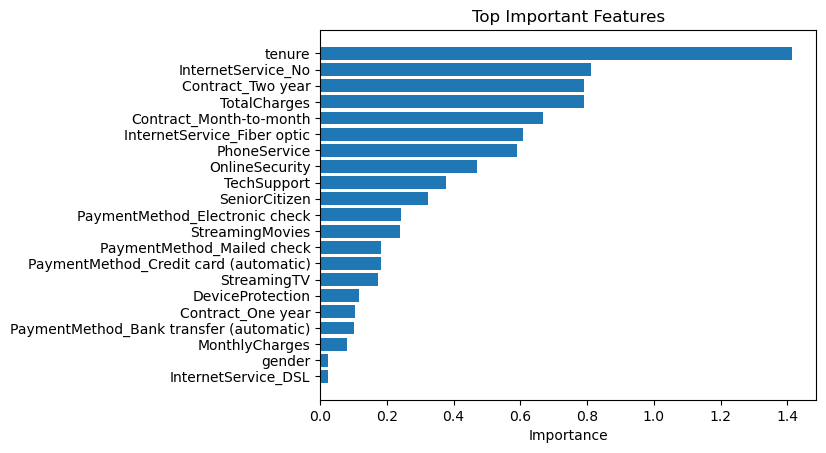

In [1074]:
import matplotlib.pyplot as plt

top_features = feature_importance

plt.barh(top_features['Feature'], top_features['Absolute Importance'])
plt.gca().invert_yaxis()
plt.title("Top Important Features")
plt.xlabel("Importance")
plt.show()

### 13. Model Saving

The trained Logistic Regression model and the scaler were saved using the Pickle library.

- The model was saved to reuse it without retraining
- The scaler was saved to ensure consistent preprocessing of new data

This allows the model to be deployed and used for predictions on new customer data.

In [1075]:
import pickle

with open("model.pkl", "wb") as f:
    pickle.dump(model, f)

with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)